# Tiny model for CIFAR10

## Configuration

Imports

In [1]:
import numpy as np
from collections import defaultdict
import matplotlib.pyplot as plt

from tqdm import tqdm, trange

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import datasets
import torchvision.transforms.v2 as transforms

Configuration

In [2]:
DATA_DIR='./data'

NUM_CLASSES = 10
NUM_WORKERS = 8
BATCH_SIZE = 32
EPOCHS = 2000
LEARNING_RATE = 1e-2
WEIGHT_DECAY = 1e-3

In [3]:
DEVICE = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print("device:", DEVICE)

device: cuda


## Data

In [4]:
train_transform = transforms.Compose([
    transforms.ToImage(),
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4, padding_mode='reflect'),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToDtype(torch.float, scale=True),
    transforms.RandomErasing(p=1.0, value=0.)
])

In [5]:
val_transform = transforms.Compose([
    transforms.ToImage(),
    transforms.ToDtype(torch.float, scale=True),
])

In [6]:
train_dset = datasets.CIFAR10(root=DATA_DIR, train=True, download=True, transform=train_transform)
test_dset = datasets.CIFAR10(root=DATA_DIR, train=False, download=True, transform=val_transform)

In [7]:
train_loader = torch.utils.data.DataLoader(train_dset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
test_loader = torch.utils.data.DataLoader(test_dset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

In [8]:
def dataset_show_image(dset, idx):
    X, Y = dset[idx]
    title = "Ground truth: {}".format(dset.classes[Y])
    fig = plt.figure()
    ax = fig.add_subplot(111)
    ax.set_axis_off()
    ax.imshow(np.moveaxis(X.numpy(), 0, -1))
    ax.set_title(title)
    plt.show()

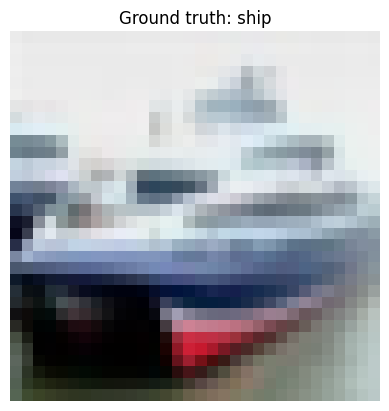

In [9]:
dataset_show_image(test_dset, 1)

## Model

From [arXiv:1904.11486 [cs.CV]](https://arxiv.org/abs/1904.11486)

In [10]:
class BlurPool(nn.Module):
    def __init__(self, stride=2, filter_size=4):
        super().__init__()
        self.stride = stride
        self.padding = (filter_size - stride) // 2
        self.register_buffer("filt", self.get_filter(filter_size))

    def forward(self, x):
        channels = x.size(1)
        filt = self.filt.expand(channels, 1, -1, -1)
        x = F.conv2d(x, filt, stride=self.stride, padding=self.padding, groups=channels)
        return x

    def get_filter(self, size):
        filt = torch.tensor(self.binomial_coefficients(size - 1)).float()
        filt = filt[:, None] * filt[None, :]
        filt = filt / filt.sum()  # normalize
        filt = filt[None, None, :, :]
        return filt

    @staticmethod
    def binomial_coefficients(n):
        coef = 1
        coefs = [coef]
        for d in range(1, n + 1):
            coef = coef * (n + 1 - d) // d
            coefs.append(coef)
        return coefs

In [11]:
class NormAct(nn.Sequential):
    def __init__(self, channels):
        super().__init__(
            nn.BatchNorm2d(channels),
        	nn.GELU()
        )

In [12]:
class ResidualBlock(nn.Module):
    def __init__(self, channels, stride=1, p_drop=0.):
        super().__init__()
        self.shortcut = nn.Dropout(p_drop)
        if stride > 1:
            self.shortcut = nn.Sequential(
                nn.AvgPool2d(stride),
                self.shortcut
            )
        layers = [
            NormAct(channels),
            nn.Conv2d(channels, channels, 3, padding=1, groups=channels, bias=False),
            NormAct(channels)
        ]
        if stride > 1:
            layers.append(BlurPool(stride, filter_size=6))
        layers.append(nn.Conv2d(channels, channels, 1, bias=False))
        self.residual = nn.Sequential(*layers)
        self.γ = nn.Parameter(torch.tensor(0.))

    def forward(self, x):
        out = self.shortcut(x) + self.γ * self.residual(x)
        return out

In [13]:
class Head(nn.Sequential):
    def __init__(self, channels, classes, p_drop=0.):
        super().__init__(
            NormAct(channels),
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Dropout(p_drop),
            nn.Linear(channels, classes)
        )

In [14]:
def Stem(in_channels, out_channels):
    return nn.Conv2d(in_channels, out_channels, 3, padding=1, bias=False)

In [15]:
class Net(nn.Sequential):
    def __init__(self, classes, width=32, in_channels=3, res_p_drop=0., head_p_drop=0.):
        strides = [1, 2, 1, 2, 1, 2, 1]
        super().__init__(
            Stem(in_channels, width),
            *[ResidualBlock(width, stride=stride, p_drop=res_p_drop) for stride in strides],
            Head(width, classes, p_drop=head_p_drop)
        )

In [16]:
def reset_parameters(model):
    for m in model.modules():
        if isinstance(m, (nn.Linear, nn.Conv2d)):
            nn.init.xavier_normal_(m.weight)
            if m.bias is not None: nn.init.zeros_(m.bias)
        elif isinstance(m, nn.BatchNorm2d):
            nn.init.constant_(m.weight, 1.)
            nn.init.zeros_(m.bias)
        elif isinstance(m, ResidualBlock):
            nn.init.zeros_(m.γ)

In [17]:
model = Net(NUM_CLASSES, width=96, res_p_drop=0.1, head_p_drop=0.1).to(DEVICE)

In [18]:
reset_parameters(model)

In [19]:
print("Number of parameters: {:,}".format(sum(p.numel() for p in model.parameters())))

Number of parameters: 77,009


## Training

### Training functions

In [20]:
def iterate(step_fn, loader):
    num_samples = 0
    total_loss = 0.
    num_correct = 0
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        loss, out = step_fn(x, y)
        pred = out.argmax(axis=-1)
        correct = (pred == y)
        loss, correct = loss.cpu().numpy(), correct.cpu().numpy()
        num_samples += correct.shape[0]
        total_loss += loss
        num_correct += np.sum(correct)
    
    avg_loss = total_loss / num_samples
    acc = num_correct / num_samples
    metrics = {"loss": avg_loss, "acc": acc}
    return metrics

In [21]:
def train(model, loss_fn, optimizer, loader, batch_scheduler):
    def train_step(x, y):
        out = model(x)
        loss = loss_fn(out, y)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        batch_scheduler.step()
        return loss.detach(), out.detach()

    model.train()
    metrics = iterate(train_step, loader)
    return metrics

In [22]:
def evaluate(model, loss_fn, loader):
    def eval_step(x, y):
        out = model(x)
        loss = loss_fn(out, y)
        return loss.detach(), out.detach()

    model.eval()
    with torch.inference_mode():
        metrics = iterate(eval_step, loader)
    return metrics

In [23]:
def update_history(history, metrics, name):
    for key, val in metrics.items():
        history[name + ' ' + key].append(val)

In [24]:
def history_plot_train_val(history, key):
    fig = plt.figure()
    ax = fig.add_subplot(111)
    xs = np.arange(1, len(history['train ' + key]) + 1)
    ax.plot(xs, history['train ' + key], '.-', label='train')
    ax.plot(xs, history['val ' + key], '.-', label='val')
    ax.set_xlabel('epoch')
    ax.set_ylabel(key)
    ax.legend()
    ax.grid()
    plt.show()

### Start training

In [25]:
loss = nn.CrossEntropyLoss()

In [26]:
optimizer = optim.AdamW([p for p in model.parameters() if p.requires_grad],
                        lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

In [27]:
lr_scheduler = optim.lr_scheduler.OneCycleLR(optimizer, max_lr=LEARNING_RATE,
                                             steps_per_epoch=len(train_loader), epochs=EPOCHS)

In [28]:
history = defaultdict(list)

In [29]:
pbar = trange(EPOCHS, ncols=140)
for epoch in pbar:
    train_metrics = train(model, loss, optimizer, train_loader, lr_scheduler)
    update_history(history, train_metrics, "train")
    
    val_metrics = evaluate(model, loss, test_loader)
    update_history(history, val_metrics, "val")
    pbar.set_postfix({"acc": train_metrics['acc'], "val acc": val_metrics['acc']})

  0%|                                                                                                              | 0/2000 [00:00<?, ?it/s]

  0%|                                                                                    | 0/2000 [00:27<?, ?it/s, acc=0.387, val acc=0.509]

  0%|                                                                         | 1/2000 [00:27<15:16:26, 27.51s/it, acc=0.387, val acc=0.509]

  0%|                                                                          | 1/2000 [00:55<15:16:26, 27.51s/it, acc=0.536, val acc=0.63]

  0%|                                                                          | 2/2000 [00:55<15:25:11, 27.78s/it, acc=0.536, val acc=0.63]

...

100%|██████████████████████████████████████████████████████████████████████▉| 1998/2000 [15:18:38<00:53, 26.62s/it, acc=0.954, val acc=0.94]

100%|██████████████████████████████████████████████████████████████████████▉| 1999/2000 [15:18:38<00:26, 26.47s/it, acc=0.954, val acc=0.94]

100%|█████████████████████████████████████████████████████████████████████▉| 1999/2000 [15:19:04<00:26, 26.47s/it, acc=0.954, val acc=0.942]

100%|██████████████████████████████████████████████████████████████████████| 2000/2000 [15:19:04<00:00, 26.16s/it, acc=0.954, val acc=0.942]

100%|██████████████████████████████████████████████████████████████████████| 2000/2000 [15:19:04<00:00, 27.57s/it, acc=0.954, val acc=0.942]

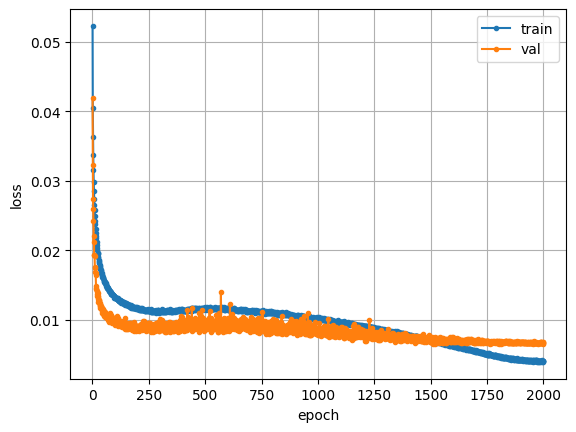

In [30]:
history_plot_train_val(history, 'loss')

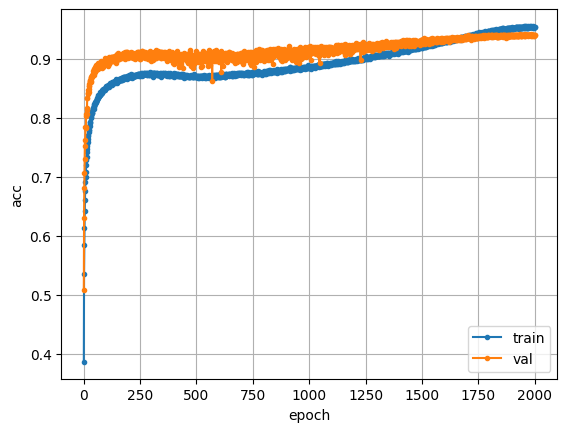

In [31]:
history_plot_train_val(history, 'acc')